In [30]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import classification_report
from sklearn.model_selection import GridSearchCV

In [31]:
class DataHandler:
  def __init__(self, file_path):
    self.file_path = file_path
    self.data = None
    self.output_df = None

  def loadData(self):
    self.data = pd.read_csv(self.file_path)
    print("data loaded!")

  def dataInfo(self):
    print("Data Info: ", self.data.info(), "\n\n")
    print("Data Head:", self.data.head())


  def valueCounts(self, column):
    print("Class Counts:")
    print(self.data[column].value_counts())


  def createInputOutput(self, target_column):
    self.output_df = self.data[target_column]
    self.input_df = self.data.drop(target_column, axis=1)

  def cekObject(self):
    print(self.data.select_dtypes(include=['object']).columns.get_level_values(0))

  def hotEncode(self, column):
    self.data = pd.get_dummies(self.data, columns=column)

  def showColumn(self):
    print(self.data.columns)

  def dropColumn(self, col):
    self.data = self.data.drop(col, axis=1)

In [32]:
class ModelHandler:
    def __init__(self, input_data, output_data):
        self.input_data = input_data
        self.output_data = output_data
        self.createModel()
        self.x_train, self.x_test, self.y_train, self.y_test, self.y_predict = [None] * 5

    def splitData(self, test_size=0.2, random_state=42):
        self.x_train, self.x_test, self.y_train, self.y_test = train_test_split(
            self.input_data, self.output_data, test_size=test_size, random_state=random_state)

    def cekMissing(self, data):
        print(data.isnull().sum())

    def checkOutlier(self, data, col):
        boxplot = data.boxplot(column=col)
        plt.show()

    def colMean(self, data, col):
        return np.mean(data[col])

    def colMedian(self, data, col):
        return np.nanmedian(data[col])

    def inputMissVal(self, data, column, value):
        data[column].fillna(value, inplace=True)

    def createModel(self, gamma= 0, learning_rate= 0.3, max_depth= 6, n_estimators= 100, subsample= 1):
        self.model = XGBClassifier(gamma= gamma, learning_rate= learning_rate, max_depth=max_depth, n_estimators=n_estimators, subsample=subsample)

    def predictModel(self):
        self.y_predict = self.model.predict(self.x_test)

    def trainModel(self):
        self.model.fit(self.x_train, self.y_train)

    def createReport(self):
        print("\nClassification Report")
        print(classification_report(self.y_test, self.y_predict))

    def tuningParams(self):
        params = {
            'n_estimators': [50, 100],
            'max_depth': [3, 5],
            'learning_rate': [0.1, 0.2],
            'subsample': [0.5, 0.7],
            'gamma': [5, 10]
        }
        XGB_class = XGBClassifier()
        XGB_class = GridSearchCV(XGB_class, param_grid = params, scoring='accuracy', cv=5)
        XGB_class.fit(self.x_train, self.y_train)
        print("Tuned Hyperparameters :", XGB_class.best_params_)
        print("Accuracy :",XGB_class.best_score_)

        self.createModel(gamma=XGB_class.best_params_['gamma'],
                         learning_rate= XGB_class.best_params_['learning_rate'],
                         max_depth= XGB_class.best_params_['max_depth'],
                         n_estimators= XGB_class.best_params_['n_estimators'], 
                         subsample= XGB_class.best_params_['subsample'])

    def saveModelToFile(self, filename):
        with open(filename, 'wb') as file:
            pickle.dump(self.model, file)

In [33]:
file_path = 'data_A.csv'
data_handler = DataHandler(file_path)
data_handler.loadData()

data_handler.dataInfo()

data loaded!
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41258 entries, 0 to 41257
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       41258 non-null  int64  
 1   id               41258 non-null  int64  
 2   CustomerId       41258 non-null  int64  
 3   Surname          41258 non-null  object 
 4   CreditScore      41238 non-null  float64
 5   Geography        41258 non-null  object 
 6   Gender           41258 non-null  object 
 7   Age              41258 non-null  float64
 8   Tenure           41258 non-null  int64  
 9   Balance          41258 non-null  float64
 10  NumOfProducts    41258 non-null  int64  
 11  HasCrCard        41258 non-null  int64  
 12  IsActiveMember   41258 non-null  int64  
 13  EstimatedSalary  41258 non-null  float64
 14  churn            41258 non-null  int64  
dtypes: float64(4), int64(8), object(3)
memory usage: 4.7+ MB
Data Info:  None 


Data Head:    

In [34]:
data_handler.showColumn()

Index(['Unnamed: 0', 'id', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'churn'],
      dtype='object')


In [35]:
data_handler.dropColumn(['Unnamed: 0', 'id', 'CustomerId', 'Surname'])

# Preprocessing

In [36]:
data_handler.cekObject()

Index(['Geography', 'Gender'], dtype='object')


In [37]:
data_handler.hotEncode(['Geography', 'Gender'])

In [39]:
data_handler.valueCounts('churn') 

data_handler.createInputOutput('churn')

# training
input_df = data_handler.input_df
output_df = data_handler.output_df

Class Counts:
0    32645
1     8613
Name: churn, dtype: int64


In [40]:
input_df.isnull().sum()

CreditScore          20
Age                   0
Tenure                0
Balance               0
NumOfProducts         0
HasCrCard             0
IsActiveMember        0
EstimatedSalary       0
Geography_France      0
Geography_Germany     0
Geography_Spain       0
Gender_Female         0
Gender_Male           0
dtype: int64

# Split data and tarining

In [41]:
model_handler = ModelHandler(input_df, output_df)
model_handler.splitData()


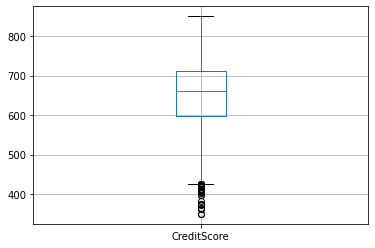

In [42]:
model_handler.checkOutlier(model_handler.x_train, 'CreditScore')

In [43]:
print(model_handler.colMedian(model_handler.x_train, 'CreditScore'))
print(model_handler.colMedian(model_handler.x_test, 'CreditScore'))

660.0
662.0


In [44]:
model_handler.inputMissVal(model_handler.x_train, 'CreditScore', model_handler.colMedian(model_handler.x_train, 'CreditScore'))
model_handler.inputMissVal(model_handler.x_test, 'CreditScore', model_handler.colMedian(model_handler.x_test, 'CreditScore'))

In [45]:
model_handler.x_test.isna().sum()

CreditScore          0
Age                  0
Tenure               0
Balance              0
NumOfProducts        0
HasCrCard            0
IsActiveMember       0
EstimatedSalary      0
Geography_France     0
Geography_Germany    0
Geography_Spain      0
Gender_Female        0
Gender_Male          0
dtype: int64

In [46]:
print("===== Untuned Params =====")
model_handler.trainModel()

model_handler.predictModel()
model_handler.createReport()

===== Untuned Params =====

Classification Report
              precision    recall  f1-score   support

           0       0.89      0.94      0.92      6545
           1       0.71      0.55      0.62      1707

    accuracy                           0.86      8252
   macro avg       0.80      0.75      0.77      8252
weighted avg       0.85      0.86      0.85      8252



# Tuning

In [49]:
print("===== Tuned")
model_handler.tuningParams()
model_handler.trainModel()
model_handler.predictModel()
model_handler.createReport()

# note if want to save into .pkl format for transfer learning
# model_handler.save_model_to_file('trained_model.pkl') 

===== Tuned
Tuned Hyperparameters : {'gamma': 10, 'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 50, 'subsample': 0.7}
Accuracy : 0.8665999721614155

Classification Report
              precision    recall  f1-score   support

           0       0.89      0.95      0.92      6545
           1       0.75      0.55      0.64      1707

    accuracy                           0.87      8252
   macro avg       0.82      0.75      0.78      8252
weighted avg       0.86      0.87      0.86      8252



In [ ]:
model_handler.save_model_to_file('trained_model.pkl') 

In [54]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
import warnings
warnings.filterwarnings('ignore')
from sklearn.metrics import classification_report

class DataHandler:
    def __init__(self, file_path):
        self.file_path = file_path
        self.data = None
        self.output_df = None

    def loadData(self):
        self.data = pd.read_csv(self.file_path)

    def createInputOutput(self, target_column):
        self.output_df = self.data[target_column]
        self.input_df = self.data.drop(target_column, axis=1)

    def hotEncode(self, column):
        self.data = pd.get_dummies(self.data, columns=column)

    def dropColumn(self, col):
        self.data = self.data.drop(col, axis=1)


class ModelHandler:
    def __init__(self, input_data, output_data):
        self.input_data = input_data
        self.output_data = output_data
        self.createModel()
        self.x_train, self.x_test, self.y_train, self.y_test, self.y_predict = [None] * 5

    def splitData(self, test_size=0.2, random_state=42):
        self.x_train, self.x_test, self.y_train, self.y_test = train_test_split(
            self.input_data, self.output_data, test_size=test_size, random_state=random_state)

    def cekMissing(self, data):
        print(data.isnull().sum())

    def checkOutlier(self, data, col):
        boxplot = data.boxplot(column=col)
        plt.show()

    def colMean(self, data, col):
        return np.mean(data[col])

    def colMedian(self, data, col):
        return np.nanmedian(data[col])

    def inputMissVal(self, data, column, value):
        data[column].fillna(value, inplace=True)

    def createModel(self, gamma= 0, learning_rate= 0.3, max_depth= 6, n_estimators= 100, subsample= 1):
        self.model = XGBClassifier(gamma= gamma, learning_rate= learning_rate, max_depth=max_depth, n_estimators=n_estimators, subsample=subsample)

    def predictModel(self):
        self.y_predict = self.model.predict(self.x_test)

    def trainModel(self):
        self.model.fit(self.x_train, self.y_train)

    def createReport(self):
        print("\nClassification Report")
        print(classification_report(self.y_test, self.y_predict))

    def tuningParams(self):
        params = {
            'n_estimators': [50, 100],
            'max_depth': [3, 5],
            'learning_rate': [0.1, 0.2],
            'subsample': [0.5, 0.7],
            'gamma': [5, 10]
        }
        XGB_class = XGBClassifier()
        XGB_class = GridSearchCV(XGB_class, param_grid = params, scoring='accuracy', cv=5)
        XGB_class.fit(self.x_train, self.y_train)
        print("Tuned Hyperparameters :", XGB_class.best_params_)
        print("Accuracy :",XGB_class.best_score_)

        self.createModel(gamma=XGB_class.best_params_['gamma'],
                         learning_rate= XGB_class.best_params_['learning_rate'],
                         max_depth= XGB_class.best_params_['max_depth'],
                         n_estimators= XGB_class.best_params_['n_estimators'], 
                         subsample= XGB_class.best_params_['subsample'])

    def saveModelToFile(self, filename):
        with open(filename, 'wb') as file:
            pickle.dump(self.model, file)

file_path = 'data_A.csv'
data_handler = DataHandler(file_path)
data_handler.loadData()

data_handler.dropColumn(['Unnamed: 0', 'id', 'CustomerId', 'Surname'])
data_handler.hotEncode(['Geography', 'Gender'])

data_handler.createInputOutput('churn')

# training
input_df = data_handler.input_df
output_df = data_handler.output_df


model_handler = ModelHandler(input_df, output_df)
model_handler.splitData()

# check outlier
# model_handler.checkOutlier(model_handler.x_train, 'CreditScore')

model_handler.inputMissVal(model_handler.x_train, 'CreditScore', model_handler.colMedian(model_handler.x_train, 'CreditScore'))
model_handler.inputMissVal(model_handler.x_test, 'CreditScore', model_handler.colMedian(model_handler.x_test, 'CreditScore'))

print("===== Untuned Params =====")
model_handler.trainModel()

model_handler.predictModel()
model_handler.createReport()


print("===== Tuned")
model_handler.tuningParams()
model_handler.trainModel()
model_handler.predictModel()
model_handler.createReport()

model_handler.saveModelToFile('trained_model.pkl') 


===== Untuned Params =====

Classification Report
              precision    recall  f1-score   support

           0       0.89      0.94      0.92      6545
           1       0.71      0.55      0.62      1707

    accuracy                           0.86      8252
   macro avg       0.80      0.75      0.77      8252
weighted avg       0.85      0.86      0.85      8252

===== Tuned
Tuned Hyperparameters : {'gamma': 10, 'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 50, 'subsample': 0.7}
Accuracy : 0.8665999721614155

Classification Report
              precision    recall  f1-score   support

           0       0.89      0.95      0.92      6545
           1       0.75      0.55      0.64      1707

    accuracy                           0.87      8252
   macro avg       0.82      0.75      0.78      8252
weighted avg       0.86      0.87      0.86      8252

